In [21]:
"""
Experimental Fluid Mechanics: Centrifugal Pump Performance Analysis
Objective: Characterize the performance curves (Head vs. Flow Rate) of two centrifugal 
pumps operating at different conditions and validate experimental results against 
manufacturer specifications using polynomial curve fitting techniques.

Pump Configuration:
- Pump 1 (Superior): Discharge and suction pressures measured in atmospheres (atm)
- Pump 2 (Inferior): Discharge pressure in atmospheres, suction pressure in water 
  column height units (cmH₂O) - represents a more typical industrial configuration

Experimental Methodology:
- Five measurement points recorded for each pump at varying flow rates
- Pressure readings from differential pressure transducers
- Flow rate measurements via calibrated orifice plate or flowmeter
- All measurements include uncertainty quantification for error propagation
- Ambient temperature and pressure documented for fluid property calculations
- Manometric head (H) calculated from pressure differential and elevation difference
- 2nd degree polynomial fitting for smooth performance curve characterization
- Experimental results compared with manufacturer specifications for validation

Libraries Used:
- pandas: Data organization and manipulation in DataFrames
- numpy: Numerical computations and polynomial fitting
- uncertainties: Automatic error propagation from measurements
- CoolProp: High-accuracy thermodynamic property calculations (water density)
- matplotlib: Visualization of performance curves and comparative analysis
"""

import pandas as pd
from uncertainties import ufloat, wrap
import numpy as np
import CoolProp.CoolProp as CP
import matplotlib.pyplot as plt

print("Libraries and environment setup complete. Ready for pump performance analysis.")

Libraries and environment setup complete. Ready for pump performance analysis.


In [22]:
"""
STEP 1: EXPERIMENTAL CONSTANTS AND UNIT CONVERSIONS
Initialize all experimental parameters, measurement uncertainties, and conversion factors
for subsequent calculations in SI units.
"""

# ============================================================================
# ENVIRONMENTAL CONDITIONS WITH MEASUREMENT UNCERTAINTIES
# ============================================================================
# These values are recorded during the laboratory session and include the 
# measurement precision limits of the instruments used

P_atm_mmHg = ufloat(698.0, 0.5)          # Atmospheric pressure [mmHg] ± 0.5 mmHg
T_amb_C = ufloat(22.0, 0.5)              # Ambient temperature [°C] ± 0.5 °C
g = ufloat(9.78, 0.01)                   # Gravitational acceleration [m/s²] ± 0.01 m/s²

# ============================================================================
# UNIT CONVERSION FACTORS (Exact Constants - No Uncertainty)
# ============================================================================
# These are defined physical constants used for unit conversions

Pa_por_atm = 101325.0                    # Conversion: 1 atm = 101325 Pa
Pa_por_mmHg_const = 133.322              # Conversion: 1 mmHg = 133.322 Pa
m3_por_L = 0.001                         # Conversion: 1 m³ = 1000 L (1 L = 0.001 m³)
s_por_h = 3600.0                         # Conversion: 1 hour = 3600 seconds
m_por_cm = 0.01                          # Conversion: 1 m = 100 cm (1 cm = 0.01 m)

# ============================================================================
# CONVERT ENVIRONMENTAL PROPERTIES TO SI UNITS
# ============================================================================
# All calculations require consistent SI unit system (K, Pa, m, etc.)

T_amb_K = T_amb_C + 273.15               # Ambient temperature [K]
P_atm_Pa = P_atm_mmHg * Pa_por_mmHg_const  # Atmospheric pressure [Pa]

# Retrieve water density using CoolProp at measured ambient conditions
# This is critical for converting pressure heads to equivalent water columns
rho_agua = CP.PropsSI('D', 'T', T_amb_K.nominal_value, 'P', P_atm_Pa.nominal_value, 'Water')

# Calculate conversion factor from water column height to Pressure in Pascals
# Formula: Pa = ρ_water * g * h
# This factor converts cmH₂O measurements to Pascals for pressure calculations
Pa_por_cmH2O = rho_agua * g * m_por_cm

print("Environmental constants and conversion factors initialized.")
print(f"  Ambient conditions: T = {T_amb_C} °C, P = {P_atm_mmHg} mmHg")
print(f"  Water density at ambient: {rho_agua:.2f} kg/m³")
print(f"  Conversion factor (cmH₂O → Pa): {Pa_por_cmH2O:.2f} Pa/cmH₂O")

Environmental constants and conversion factors initialized.
  Ambient conditions: T = 22.0+/-0.5 °C, P = 698.0+/-0.5 mmHg
  Water density at ambient: 997.77 kg/m³
  Conversion factor (cmH₂O → Pa): 97.58+/-0.10 Pa/cmH₂O


In [23]:
"""
STEP 3: LOAD EXPERIMENTAL DATA - PUMP 2 (INFERIOR)

Pump 2 Configuration:
- Discharge pressure measured in atmospheres (standard pressure gauge)
- Suction pressure measured in water column height units (cmH₂O via manometer)
- This mixed-unit setup is common in industrial centrifugal pump testing facilities
- 5 measurement points acquired at same flow rates as Pump 1 for comparison
- Different elevation offset reflects different physical mounting on test bench
"""

# ============================================================================
# PUMP 2 DATA: Mixed Pressure Units and Flow Rate Measurements
# ============================================================================
# Note the difference in suction pressure units - this requires unit conversion
# in the calculation phase

data_inferior = {
    'P_r_inf_atm': [ufloat(2.150, 0.025), ufloat(2.400, 0.025), ufloat(2.500, 0.025), 
                    ufloat(2.700, 0.025), ufloat(2.750, 0.025)],  # Discharge pressure [atm] ± 0.025 atm
    'P_s_inf_cmH2O': [ufloat(40.20, 0.05), ufloat(42.70, 0.05), ufloat(44.10, 0.05), 
                      ufloat(45.40, 0.05), ufloat(47.40, 0.05)],  # Suction pressure [cmH₂O] ± 0.05 cm
                                                                  # Direct manometer reading (positive values only)
    'Q_inf_Lh': [ufloat(7500, 250), ufloat(6000, 250), ufloat(5000, 250), 
                 ufloat(4000, 250), ufloat(3000, 250)]           # Flow rate [L/h] ± 250 L/h
}

# Create DataFrame for organized data storage
df_inferior = pd.DataFrame(data_inferior, index=range(1, 6))
df_inferior.index.name = 'Measurement Point'

# Convert flow rates from L/h to m³/h for SI unit consistency
df_inferior['Q_inf_m3h'] = df_inferior['Q_inf_Lh'] * m3_por_L  # [m³/h]

# Elevation difference between pressure measurement taps
# Larger offset than Pump 1 due to different physical location on test bench
m_inf_m = ufloat(51.40, 0.05) * m_por_cm  # [m] ± 0.05 cm

print("Pump 2 (Inferior) experimental data loaded.")
print(f"  Number of measurement points: {len(df_inferior)}")
print(f"  Flow rate range: {df_inferior['Q_inf_Lh'].iloc[0]} to {df_inferior['Q_inf_Lh'].iloc[-1]}")
print(f"  Elevation offset: {m_inf_m} m")
print("\nBoth pumps ready for manometric head calculations.")

Pump 2 (Inferior) experimental data loaded.
  Number of measurement points: 5
  Flow rate range: (7.50+/-0.25)e+03 to (3.00+/-0.25)e+03
  Elevation offset: 0.5140+/-0.0005 m

Both pumps ready for manometric head calculations.


In [24]:
"""
STEP 2: LOAD EXPERIMENTAL DATA - PUMP 1 (SUPERIOR)

Pump 1 Configuration:
- Both discharge (recalque) and suction (sucção) pressures measured in atmospheres
- 5 measurement points spanning from low to high flow rates
- Measurements include uncertainties from pressure transducer precision
- Elevation difference between discharge and suction pressure tap points must be 
  accounted for in manometric head calculation
"""

# ============================================================================
# PUMP 1 DATA: Pressure and Flow Rate Measurements
# ============================================================================
# Each measurement point represents steady-state operation at different throttle positions
# Uncertainties reflect instrument precision and reading repeatability

data_superior = {
    'P_r_sup_atm': [ufloat(2.30, 0.05), ufloat(2.50, 0.05), ufloat(2.60, 0.05), 
                    ufloat(2.70, 0.05), ufloat(2.80, 0.05)],  # Discharge pressure [atm] ± 0.05 atm
    'P_s_sup_atm': [ufloat(-0.10, 0.05), ufloat(-0.10, 0.05), ufloat(-0.10, 0.05), 
                    ufloat(0.00, 0.05), ufloat(0.00, 0.05)],   # Suction pressure [atm] ± 0.05 atm
                                                               # Negative values indicate vacuum (below atmospheric)
    'Q_sup_Lh': [ufloat(7500, 250), ufloat(6000, 250), ufloat(5000, 250), 
                 ufloat(4000, 250), ufloat(3000, 250)]         # Flow rate [L/h] ± 250 L/h
}

# Create DataFrame for organized data storage
df_superior = pd.DataFrame(data_superior, index=range(1, 6))
df_superior.index.name = 'Measurement Point'

# Convert flow rates from L/h to m³/h for SI unit consistency
df_superior['Q_sup_m3h'] = df_superior['Q_sup_Lh'] * m3_por_L  # [m³/h]

# Elevation difference between pressure measurement taps
# Positive value indicates discharge tap is higher than suction tap
# Must be added to pressure-based head calculation
m_sup_m = ufloat(38.40, 0.05) * m_por_cm  # [m] ± 0.05 cm

print("Pump 1 (Superior) experimental data loaded.")
print(f"  Number of measurement points: {len(df_superior)}")
print(f"  Flow rate range: {df_superior['Q_sup_Lh'].iloc[0]} to {df_superior['Q_sup_Lh'].iloc[-1]}")
print(f"  Elevation offset: {m_sup_m} m")

Pump 1 (Superior) experimental data loaded.
  Number of measurement points: 5
  Flow rate range: (7.50+/-0.25)e+03 to (3.00+/-0.25)e+03
  Elevation offset: 0.3840+/-0.0005 m


In [25]:
"""
STEP 4: DISPLAY PUMP 1 RAW EXPERIMENTAL DATA

This cell displays the raw measurements collected for Pump 1 (Superior) without any 
processing. The DataFrame shows:
- Discharge pressure (P_r_sup_atm) in atmospheres
- Suction pressure (P_s_sup_atm) in atmospheres  
- Flow rate (Q_sup_Lh) in liters per hour
- Converted flow rate (Q_sup_m3h) in cubic meters per hour

All values are presented with their measurement uncertainties.
"""

print("=" * 90)
print("PUMP 1 (SUPERIOR): Raw Experimental Measurements")
print("=" * 90)
print("\nConfiguration: Discharge and Suction Pressures in Atmospheres (atm)")
print("Number of measurement points: 5")
print("-" * 90)

df_superior

PUMP 1 (SUPERIOR): Raw Experimental Measurements

Configuration: Discharge and Suction Pressures in Atmospheres (atm)
Number of measurement points: 5
------------------------------------------------------------------------------------------


,P_r_sup_atm,P_s_sup_atm,Q_sup_Lh,Q_sup_m3h
Measurement Point,,,,
1,2.30+/-0.05,-0.10+/-0.05,(7.50+/-0.25)e+03,7.50+/-0.25
2,2.50+/-0.05,-0.10+/-0.05,(6.00+/-0.25)e+03,6.00+/-0.25
3,2.60+/-0.05,-0.10+/-0.05,(5.00+/-0.25)e+03,5.00+/-0.25
4,2.70+/-0.05,0.00+/-0.05,(4.00+/-0.25)e+03,4.00+/-0.25
5,2.80+/-0.05,0.00+/-0.05,(3.00+/-0.25)e+03,3.00+/-0.25


In [26]:
"""
STEP 5: DISPLAY PUMP 2 RAW EXPERIMENTAL DATA

This cell displays the raw measurements collected for Pump 2 (Inferior) without any 
processing. The DataFrame shows:
- Discharge pressure (P_r_inf_atm) in atmospheres
- Suction pressure (P_s_inf_cmH2O) in water column height (centimeters)
- Flow rate (Q_inf_Lh) in liters per hour
- Converted flow rate (Q_inf_m3h) in cubic meters per hour

Note the mixed pressure units: discharge in atm, suction in cmH₂O. Both will be 
converted to Pascals (Pa) for unified calculations.
"""

print("=" * 90)
print("PUMP 2 (INFERIOR): Raw Experimental Measurements")
print("=" * 90)
print("\nConfiguration: Discharge in Atmospheres (atm), Suction in Water Column (cmH₂O)")
print("Number of measurement points: 5")
print("Note: Suction pressure directly from manometer reading (positive values)")
print("-" * 90)

df_inferior

PUMP 2 (INFERIOR): Raw Experimental Measurements

Configuration: Discharge in Atmospheres (atm), Suction in Water Column (cmH₂O)
Number of measurement points: 5
Note: Suction pressure directly from manometer reading (positive values)
------------------------------------------------------------------------------------------


,P_r_inf_atm,P_s_inf_cmH2O,Q_inf_Lh,Q_inf_m3h
Measurement Point,,,,
1,2.150+/-0.025,40.20+/-0.05,(7.50+/-0.25)e+03,7.50+/-0.25
2,2.400+/-0.025,42.70+/-0.05,(6.00+/-0.25)e+03,6.00+/-0.25
3,2.500+/-0.025,44.10+/-0.05,(5.00+/-0.25)e+03,5.00+/-0.25
4,2.700+/-0.025,45.40+/-0.05,(4.00+/-0.25)e+03,4.00+/-0.25
5,2.750+/-0.025,47.40+/-0.05,(3.00+/-0.25)e+03,3.00+/-0.25


In [27]:
"""
STEP 6: CALCULATE MANOMETRIC HEAD - PUMP 1 (SUPERIOR)

Manometric Head Calculation Theory:
The manometric head (H_man) represents the total pressure head developed by the pump.
It accounts for:
1. Pressure difference between discharge and suction
2. Elevation difference between pressure measurement points
3. Normalization by fluid density and gravitational acceleration

Formula:
    H_man = (P_discharge - P_suction) / (ρ_water * g) + Δh_elevation

Where:
    H_man: Manometric head [m.c.a. - meters of water column]
    P_discharge, P_suction: Pressures in Pascals [Pa]
    ρ_water: Water density at ambient conditions [kg/m³]
    g: Gravitational acceleration [m/s²]
    Δh_elevation: Elevation difference between measurement taps [m]

This calculation converts all pressure measurements to equivalent water column height,
providing a unified measure of pump performance across different conditions.
"""

def calcular_H_man_superior(row):
    """
    Calculates manometric head for Pump 1 (Superior) from pressure measurements.
    
    Parameters:
        row (pd.Series): Single row from df_superior DataFrame containing:
            - P_r_sup_atm: Discharge pressure [atm]
            - P_s_sup_atm: Suction pressure [atm]
    
    Returns:
        ufloat: Manometric head with propagated uncertainty [m.c.a.]
    
    Physical Interpretation:
        This represents the height of water column an equivalent amount of water
        would reach if the pressure energy were converted to potential energy.
    """
    # Extract pressure values from the row
    P_r_atm = row['P_r_sup_atm']        # Discharge pressure [atm]
    P_s_atm = row['P_s_sup_atm']        # Suction pressure [atm]

    # Convert pressures from atmospheres to Pascals
    # Using pre-calculated conversion factor: 1 atm = 101325 Pa
    P_r_Pa = P_r_atm * Pa_por_atm       # Discharge pressure [Pa]
    P_s_Pa = P_s_atm * Pa_por_atm       # Suction pressure [Pa]

    # Calculate pressure head component
    # Divide pressure difference by (density * gravity) to get equivalent height
    H_pressure = (P_r_Pa - P_s_Pa) / (rho_agua * g)
    
    # Add elevation component (measured height difference between pressure taps)
    H_man = H_pressure + m_sup_m
    
    return H_man

# Apply calculation to all measurement points in Pump 1 DataFrame
df_superior['H_man (m)'] = df_superior.apply(calcular_H_man_superior, axis=1)

print("=" * 90)
print("PUMP 1 (SUPERIOR): Manometric Head Calculations Completed")
print("=" * 90)
print("\nFormula used: H_man = (P_discharge - P_suction) / (ρ * g) + Δh_elevation")
print(f"Water density used: {rho_agua:.2f} kg/m³")
print(f"Gravitational acceleration: {g} m/s²")
print(f"Elevation offset (m_sup): {m_sup_m} m")
print("-" * 90)

df_superior

PUMP 1 (SUPERIOR): Manometric Head Calculations Completed

Formula used: H_man = (P_discharge - P_suction) / (ρ * g) + Δh_elevation
Water density used: 997.77 kg/m³
Gravitational acceleration: 9.780+/-0.010 m/s²
Elevation offset (m_sup): 0.3840+/-0.0005 m
------------------------------------------------------------------------------------------


,P_r_sup_atm,P_s_sup_atm,Q_sup_Lh,Q_sup_m3h,H_man (m)
Measurement Point,,,,,
1,2.30+/-0.05,-0.10+/-0.05,(7.50+/-0.25)e+03,7.50+/-0.25,25.3+/-0.7
2,2.50+/-0.05,-0.10+/-0.05,(6.00+/-0.25)e+03,6.00+/-0.25,27.4+/-0.7
3,2.60+/-0.05,-0.10+/-0.05,(5.00+/-0.25)e+03,5.00+/-0.25,28.4+/-0.7
4,2.70+/-0.05,0.00+/-0.05,(4.00+/-0.25)e+03,4.00+/-0.25,28.4+/-0.7
5,2.80+/-0.05,0.00+/-0.05,(3.00+/-0.25)e+03,3.00+/-0.25,29.5+/-0.7


In [28]:
"""
STEP 7: CALCULATE MANOMETRIC HEAD - PUMP 2 (INFERIOR)

Key Difference from Pump 1:
This pump uses different pressure units for discharge and suction:
- Discharge pressure: Atmospheres (atm) - from pressure gauge
- Suction pressure: Water column height (cmH₂O) - from direct manometer reading

Unit Conversion Required:
Both pressures must be converted to Pascals (Pa) before calculation:
    1. Discharge: P_Pa = P_atm * 101325 Pa/atm
    2. Suction: P_Pa = P_cmH2O * ρ_water * g * h_conversion

The conversion factor (Pa_por_cmH2O) was pre-calculated as:
    Pa_por_cmH2O = ρ_water * g * 0.01 m

This approach reflects typical industrial pump testing where different 
pressure measurement instruments may use different units.
"""

def calcular_H_man_inferior(row):
    """
    Calculates manometric head for Pump 2 (Inferior) from mixed-unit pressure measurements.
    
    Parameters:
        row (pd.Series): Single row from df_inferior DataFrame containing:
            - P_r_inf_atm: Discharge pressure [atm]
            - P_s_inf_cmH2O: Suction pressure [cmH₂O]
    
    Returns:
        ufloat: Manometric head with propagated uncertainty [m.c.a.]
    
    Unit Handling:
        This function handles the conversion of mixed pressure units (atm and cmH₂O)
        to consistent SI units (Pa) before calculation.
    """
    # Extract pressure values from the row
    P_r_atm = row['P_r_inf_atm']        # Discharge pressure [atm]
    P_s_cmH2O = row['P_s_inf_cmH2O']    # Suction pressure [cmH₂O]

    # Convert discharge pressure from atmospheres to Pascals
    P_r_Pa = P_r_atm * Pa_por_atm         # Discharge pressure [Pa]
    
    # Convert suction pressure from water column height to Pascals
    # P = ρ_water * g * h (where h is in meters)
    # Pre-calculated factor includes the 0.01 m conversion from cm to m
    P_s_Pa = P_s_cmH2O * Pa_por_cmH2O    # Suction pressure [Pa]

    # Calculate pressure head component
    H_pressure = (P_r_Pa - P_s_Pa) / (rho_agua * g)
    
    # Add elevation component (measured height difference between pressure taps)
    H_man = H_pressure + m_inf_m
    
    return H_man

# Apply calculation to all measurement points in Pump 2 DataFrame
df_inferior['H_man (m)'] = df_inferior.apply(calcular_H_man_inferior, axis=1)

print("=" * 90)
print("PUMP 2 (INFERIOR): Manometric Head Calculations Completed")
print("=" * 90)
print("\nFormula used: H_man = (P_discharge - P_suction) / (ρ * g) + Δh_elevation")
print(f"Discharge pressure units: Atmospheres [atm]")
print(f"Suction pressure units: Water column height [cmH₂O]")
print(f"Water density used: {rho_agua:.2f} kg/m³")
print(f"Gravitational acceleration: {g} m/s²")
print(f"Elevation offset (m_inf): {m_inf_m} m")
print("-" * 90)

df_inferior

PUMP 2 (INFERIOR): Manometric Head Calculations Completed

Formula used: H_man = (P_discharge - P_suction) / (ρ * g) + Δh_elevation
Discharge pressure units: Atmospheres [atm]
Suction pressure units: Water column height [cmH₂O]
Water density used: 997.77 kg/m³
Gravitational acceleration: 9.780+/-0.010 m/s²
Elevation offset (m_inf): 0.5140+/-0.0005 m
------------------------------------------------------------------------------------------


,P_r_inf_atm,P_s_inf_cmH2O,Q_inf_Lh,Q_inf_m3h,H_man (m)
Measurement Point,,,,,
1,2.150+/-0.025,40.20+/-0.05,(7.50+/-0.25)e+03,7.50+/-0.25,22.44+/-0.26
2,2.400+/-0.025,42.70+/-0.05,(6.00+/-0.25)e+03,6.00+/-0.25,25.01+/-0.26
3,2.500+/-0.025,44.10+/-0.05,(5.00+/-0.25)e+03,5.00+/-0.25,26.03+/-0.26
4,2.700+/-0.025,45.40+/-0.05,(4.00+/-0.25)e+03,4.00+/-0.25,28.10+/-0.26
5,2.750+/-0.025,47.40+/-0.05,(3.00+/-0.25)e+03,3.00+/-0.25,28.59+/-0.26


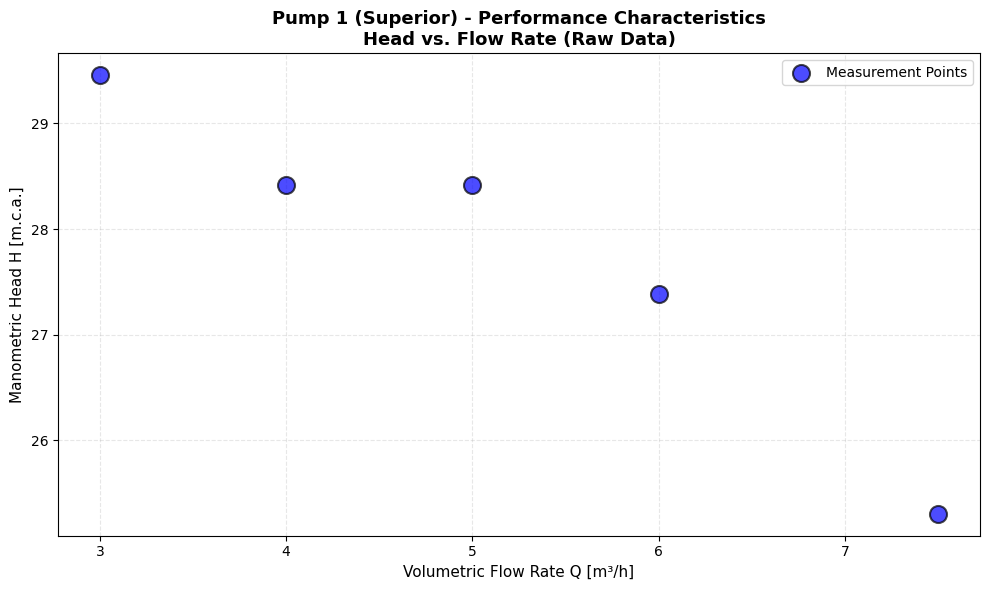

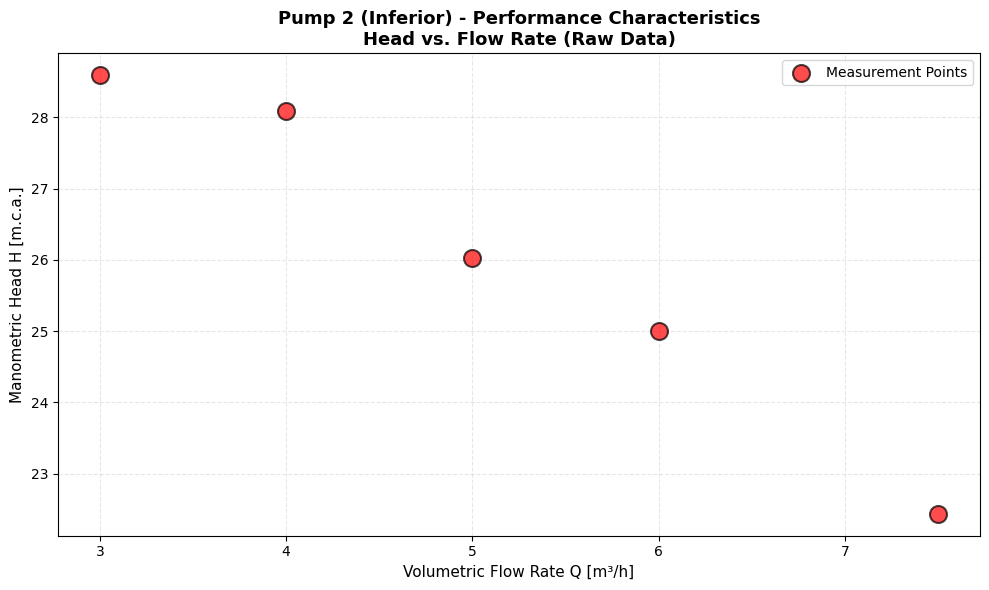

Initial scatter plots generated for both pumps.


In [29]:
"""
STEP 8: PLOT INITIAL PERFORMANCE CURVES - SCATTER PLOTS ONLY

Purpose:
This step generates scatter plots of raw experimental data for each pump.
These unprocessed visualizations show the relationship between:
    X-axis: Volumetric flow rate (Q) [m³/h]
    Y-axis: Manometric head (H) [m.c.a.]

These raw data points will serve as the basis for polynomial curve fitting 
in the subsequent analysis section.

Typical Pump Behavior:
Centrifugal pumps exhibit an inverse relationship between flow rate and head:
- At shut-off (Q = 0): Maximum head (H_max)
- At best efficiency point (BEP): Optimal H vs Q relationship
- At maximum flow (Q_max): Minimum head (H_min)
"""

# ============================================================================
# PUMP 1 (SUPERIOR): Head vs. Flow Rate Scatter Plot
# ============================================================================

plt.figure(figsize=(10, 6))
plt.grid(True, alpha=0.3, linestyle='--')
plt.title('Pump 1 (Superior) - Performance Characteristics\nHead vs. Flow Rate (Raw Data)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Volumetric Flow Rate Q [m³/h]', fontsize=11)
plt.ylabel('Manometric Head H [m.c.a.]', fontsize=11)

# Extract nominal values from ufloat measurements for plotting
Q_sup_nominal = df_superior['Q_sup_m3h'].apply(lambda x: x.nominal_value)
H_sup_nominal = df_superior['H_man (m)'].apply(lambda x: x.nominal_value)

# Plot experimental data points
plt.scatter(Q_sup_nominal, H_sup_nominal, 
            color='blue', s=150, alpha=0.7, label='Measurement Points', 
            edgecolors='black', linewidth=1.5, zorder=3)

plt.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.show()

# ============================================================================
# PUMP 2 (INFERIOR): Head vs. Flow Rate Scatter Plot
# ============================================================================

plt.figure(figsize=(10, 6))
plt.grid(True, alpha=0.3, linestyle='--')
plt.title('Pump 2 (Inferior) - Performance Characteristics\nHead vs. Flow Rate (Raw Data)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Volumetric Flow Rate Q [m³/h]', fontsize=11)
plt.ylabel('Manometric Head H [m.c.a.]', fontsize=11)

# Extract nominal values from ufloat measurements for plotting
Q_inf_nominal = df_inferior['Q_inf_m3h'].apply(lambda x: x.nominal_value)
H_inf_nominal = df_inferior['H_man (m)'].apply(lambda x: x.nominal_value)

# Plot experimental data points
plt.scatter(Q_inf_nominal, H_inf_nominal, 
            color='red', s=150, alpha=0.7, label='Measurement Points', 
            edgecolors='black', linewidth=1.5, zorder=3)

plt.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.show()

print("Initial scatter plots generated for both pumps.")

Generating Pump 1 (Superior) performance curve with polynomial fitting...


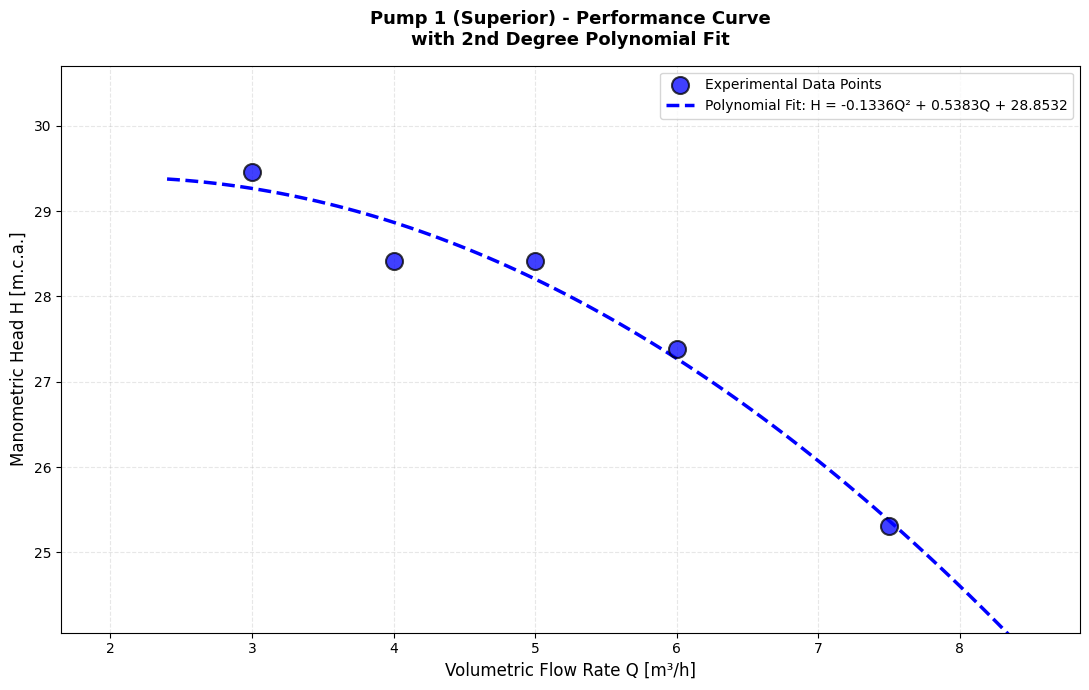

Generating Pump 2 (Inferior) performance curve with polynomial fitting...


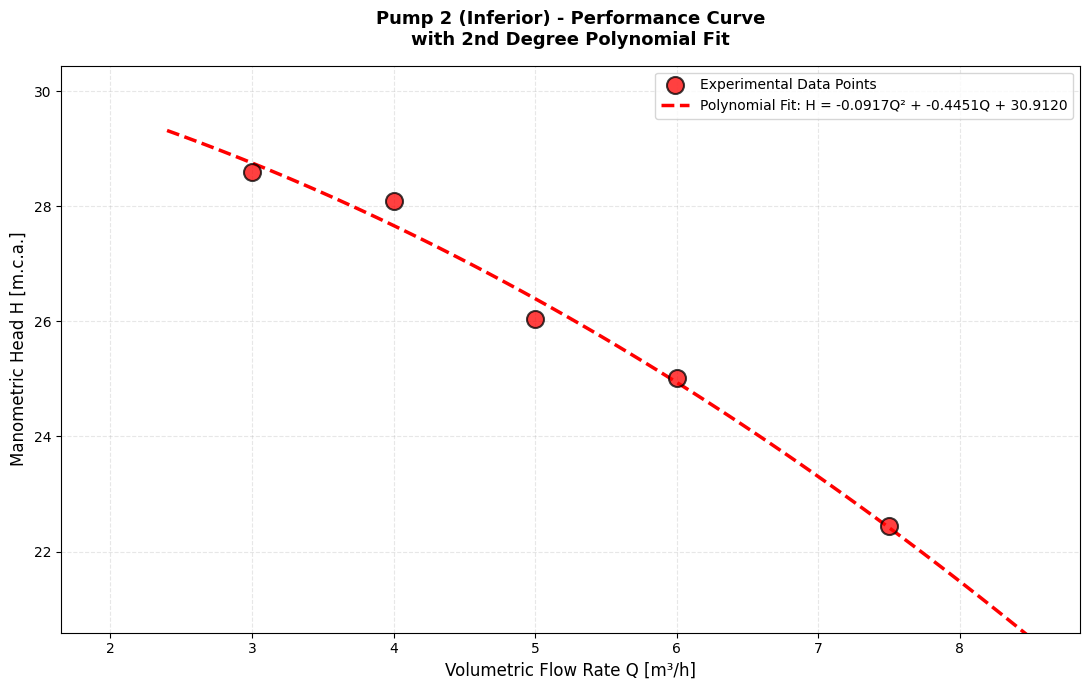

Individual pump performance curves completed.


In [30]:
"""
STEP 9: INDIVIDUAL PUMP PERFORMANCE CURVES WITH POLYNOMIAL FITTING

Polynomial Curve Fitting Theory:
A 2nd degree polynomial (quadratic function) is fitted to the experimental data
using the least-squares method via numpy.polyfit().

Mathematical Formulation:
    H(Q) = a*Q² + b*Q + c

Where:
    H: Manometric head [m.c.a.]
    Q: Volumetric flow rate [m³/h]
    a, b, c: Polynomial coefficients determined by fitting

Advantages of 2nd Degree Polynomial:
1. Simplicity: Only 3 coefficients for calculation
2. Physical Validity: Matches typical centrifugal pump characteristic curves
3. Smoothness: Avoids overfitting while capturing main trend
4. Extrapolation: Allows performance prediction between measured points

This approach provides a smooth performance curve representation and enables
performance estimation at conditions between measurement points.
"""

def plot_individual_pump_curves(df, q_col, h_col, titulo, cor):
    """
    Generates and plots a 2nd degree polynomial fit to pump performance data.
    
    Parameters:
        df (pd.DataFrame): DataFrame containing flow rate and head data
        q_col (str): Column name for volumetric flow rate [m³/h]
        h_col (str): Column name for manometric head [m.c.a.]
        titulo (str): Title for the generated plot
        cor (str): Color for plotting (matplotlib color name)
    
    Returns:
        None (displays matplotlib figure)
    
    Process:
        1. Extract nominal values from ufloat measurements
        2. Fit 2nd degree polynomial using least-squares approximation
        3. Generate smooth curve with 100 interpolated points
        4. Plot experimental data and fitted curve with proper formatting
        5. Adjust axis limits for optimal visualization
    """
    # Extract nominal values from uncertainty-weighted measurements
    # We use nominal values because the polynomial fitting works on pure numbers
    Q_data = df[q_col].apply(lambda x: x.nominal_value).values
    H_data = df[h_col].apply(lambda x: x.nominal_value).values

    # Perform 2nd degree polynomial fitting using least-squares method
    # np.polyfit returns coefficients in descending order: [a, b, c] for a*Q² + b*Q + c
    coef = np.polyfit(Q_data, H_data, 2)
    polynomial = np.poly1d(coef)

    # Generate smooth curve points for visualization
    # Extend the range by 20% on each side to show pump behavior beyond measured points
    Q_smooth = np.linspace(min(Q_data) * 0.8, max(Q_data) * 1.2, 100)
    H_smooth = polynomial(Q_smooth)

    # Create figure with appropriate size
    plt.figure(figsize=(11, 7))
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.title(titulo, fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Volumetric Flow Rate Q [m³/h]', fontsize=12)
    plt.ylabel('Manometric Head H [m.c.a.]', fontsize=12)

    # Plot experimental data points with error emphasis
    plt.scatter(Q_data, H_data, 
                color=cor, s=150, alpha=0.75, label='Experimental Data Points', 
                edgecolors='black', linewidth=1.5, zorder=3)

    # Plot fitted polynomial curve
    plt.plot(Q_smooth, H_smooth, 
             color=cor, linestyle='--', linewidth=2.5, 
             label=f'Polynomial Fit: H = {coef[0]:.4f}Q² + {coef[1]:.4f}Q + {coef[2]:.4f}', 
             zorder=2)

    # Adjust plot limits for better visualization
    margin_x = (max(Q_data) - min(Q_data)) * 0.3
    margin_y = (max(H_data) - min(H_data)) * 0.3

    plt.xlim(min(Q_data) - margin_x, max(Q_data) + margin_x)
    plt.ylim(min(H_data) - margin_y, max(H_data) + margin_y)

    plt.legend(fontsize=10, loc='best')
    plt.tight_layout()
    plt.show()

# ============================================================================
# PUMP 1 - SUPERIOR: Individual Performance Curve
# ============================================================================

print("Generating Pump 1 (Superior) performance curve with polynomial fitting...")
plot_individual_pump_curves(df_superior, 'Q_sup_m3h', 'H_man (m)', 
                            'Pump 1 (Superior) - Performance Curve\nwith 2nd Degree Polynomial Fit', 
                            'blue')

# ============================================================================
# PUMP 2 - INFERIOR: Individual Performance Curve  
# ============================================================================

print("Generating Pump 2 (Inferior) performance curve with polynomial fitting...")
plot_individual_pump_curves(df_inferior, 'Q_inf_m3h', 'H_man (m)', 
                            'Pump 2 (Inferior) - Performance Curve\nwith 2nd Degree Polynomial Fit', 
                            'red')

print("Individual pump performance curves completed.")

In [31]:
"""
STEP 10: LOAD MANUFACTURER PERFORMANCE DATA FOR COMPARISON

Purpose:
Reference data from pump manufacturer specifications is used to validate
experimental results. This enables assessment of:
1. Measurement accuracy and procedure validity
2. Pump operational condition (new vs. worn)
3. Deviation from expected performance characteristics

Manufacturer Data:
Typically provided as tabulated performance curves or nominal specifications
at standard operating conditions (e.g., at specific speed, temperature, fluid).
These data represent the pump's theoretical ideal performance.

Note:
This reference data is typically from pump datasheets and represents performance
at reference conditions that may differ from lab conditions. Differences between
experimental and manufacturer data can indicate:
- Wear and fouling of pump internals
- Deviation from reference operating conditions
- Measurement uncertainty
- Cavitation or off-design operation
"""

# ============================================================================
# MANUFACTURER REFERENCE PERFORMANCE DATA
# ============================================================================
# These are specification values provided by the pump manufacturer
# representing nominal pump performance at reference conditions

dados_fabricante = pd.DataFrame({
    'Q_fabricante_m3h': [0.0, 4.1, 6.0, 6.6, 7.4],            # Flow rates [m³/h]
    'H_fabricante_m': [30.0, 28.0, 26.0, 25.0, 24.0]          # Manometric heads [m.c.a.]
})

print("=" * 90)
print("MANUFACTURER REFERENCE DATA: Performance Specification")
print("=" * 90)
print(f"Number of reference points: {len(dados_fabricante)}")
print(f"Flow rate range: {dados_fabricante['Q_fabricante_m3h'].min():.1f} to {dados_fabricante['Q_fabricante_m3h'].max():.1f} m³/h")
print(f"Head range: {dados_fabricante['H_fabricante_m'].min():.1f} to {dados_fabricante['H_fabricante_m'].max():.1f} m.c.a.")
print("-" * 90)

print("\nManufacturer Data Table:")
print(dados_fabricante.to_string())

MANUFACTURER REFERENCE DATA: Performance Specification
Number of reference points: 5
Flow rate range: 0.0 to 7.4 m³/h
Head range: 24.0 to 30.0 m.c.a.
------------------------------------------------------------------------------------------

Manufacturer Data Table:
   Q_fabricante_m3h  H_fabricante_m
0               0.0            30.0
1               4.1            28.0
2               6.0            26.0
3               6.6            25.0
4               7.4            24.0


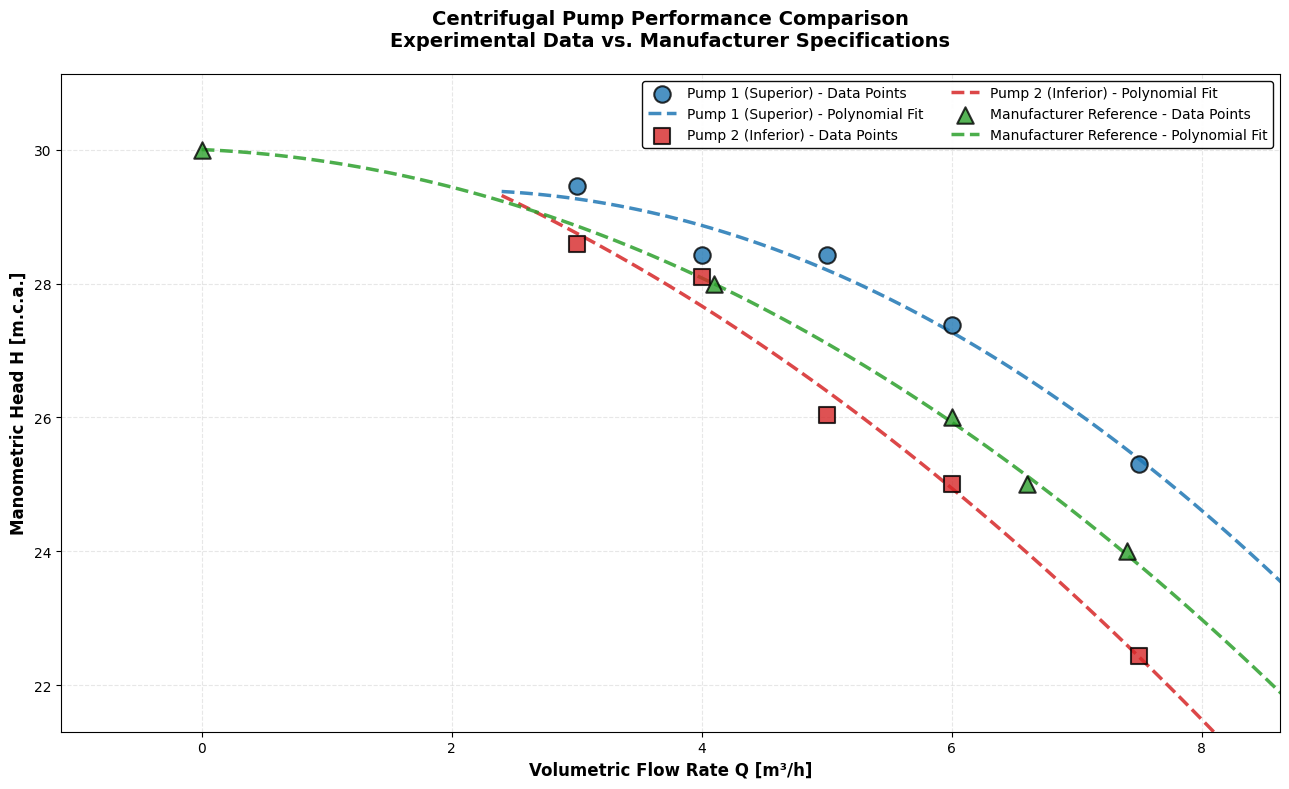

PUMP PERFORMANCE ANALYSIS SUMMARY

Pump 1 (Superior) - Experimental Results:
  Flow rate range: 3.00 - 7.50 m³/h
  Head range: 25.30 - 29.46 m.c.a.

Pump 2 (Inferior) - Experimental Results:
  Flow rate range: 3.00 - 7.50 m³/h
  Head range: 22.44 - 28.59 m.c.a.

Manufacturer Reference:
  Flow rate range: 0.00 - 7.40 m³/h
  Head range: 24.00 - 30.00 m.c.a.

ANALYSIS COMPLETE


In [32]:
"""
STEP 11: COMPARATIVE PERFORMANCE ANALYSIS - ALL CURVES ON SINGLE PLOT

Comprehensive Comparison:
This final visualization presents a unified comparison of:
1. Pump 1 (Superior) - Experimental measurements with polynomial fit
2. Pump 2 (Inferior) - Experimental measurements with polynomial fit
3. Manufacturer Reference - Specification performance curve

Interpretation Guide:
- Curves closely aligned: Pump performance matches manufacturer specification
- Curves divergent at high flow: Possible cavitation or wear at high capacity
- Curves divergent at low flow: Possible recirculation or off-design operation
- Curve below reference: May indicate pump wear, fouling, or operating condition mismatch

Analysis Capabilities:
This comparison enables:
• Assessment of pump condition relative to new specification
• Identification of operating mode issues (cavitation, recirculation)
• Performance consistency between similar pumps (Pump 1 vs Pump 2)
• Validation of experimental methodology
• Basis for maintenance decisions and performance trending
"""

def extract_nominal_values(series):
    """
    Extracts nominal (best estimate) values from pandas Series containing ufloat objects.
    
    Parameters:
        series (pd.Series): Series potentially containing ufloat measurements with uncertainties
    
    Returns:
        np.ndarray: Array of nominal values (pure floats without uncertainty information)
    
    Logic:
        - If series elements have 'nominal_value' attribute → ufloat objects with uncertainty
        - Otherwise → regular float values that can be plotted directly
    
    This handling allows the function to work with both measured data (ufloat)
    and manufacturer specifications (regular float).
    """
    if hasattr(series.iloc[0], 'nominal_value'):
        return series.apply(lambda x: x.nominal_value).values
    return series.values

# ============================================================================
# COMBINED PERFORMANCE COMPARISON: Experimental vs. Manufacturer Reference
# ============================================================================

fig = plt.figure(figsize=(13, 8))
ax = fig.add_subplot(111)

# Configure grid and labels
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_title('Centrifugal Pump Performance Comparison\nExperimental Data vs. Manufacturer Specifications', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Volumetric Flow Rate Q [m³/h]', fontsize=12, fontweight='bold')
ax.set_ylabel('Manometric Head H [m.c.a.]', fontsize=12, fontweight='bold')

# ============================================================================
# DATA ORGANIZATION FOR CONSISTENT PROCESSING
# ============================================================================
# Use dictionary to organize all datasets with consistent structure

datasets_comparison = {
    'Pump 1 (Superior)': {
        'dataframe': df_superior,
        'q_column': 'Q_sup_m3h',
        'h_column': 'H_man (m)',
        'color': '#1f77b4',      # Blue
        'marker': 'o',
        'line_style': '--'
    },
    'Pump 2 (Inferior)': {
        'dataframe': df_inferior,
        'q_column': 'Q_inf_m3h',
        'h_column': 'H_man (m)',
        'color': '#d62728',      # Red
        'marker': 's',
        'line_style': '--'
    },
    'Manufacturer Reference': {
        'dataframe': dados_fabricante,
        'q_column': 'Q_fabricante_m3h',
        'h_column': 'H_fabricante_m',
        'color': '#2ca02c',      # Green
        'marker': '^',
        'line_style': '--'
    }
}

all_flow_rates = []
all_heads = []

# ============================================================================
# PLOT EACH DATASET WITH POLYNOMIAL FIT
# ============================================================================

for dataset_name, dataset_config in datasets_comparison.items():
    df = dataset_config['dataframe']
    q_col = dataset_config['q_column']
    h_col = dataset_config['h_column']
    color = dataset_config['color']
    marker = dataset_config['marker']
    line_style = dataset_config['line_style']

    # Extract nominal values (handles both ufloat and regular float)
    Q_values = extract_nominal_values(df[q_col])
    H_values = extract_nominal_values(df[h_col])

    # Track all data for axis scaling
    all_flow_rates.extend(Q_values)
    all_heads.extend(H_values)

    # Perform 2nd degree polynomial fitting
    coefficients = np.polyfit(Q_values, H_values, 2)
    polynomial_fit = np.poly1d(coefficients)

    # Generate smooth curve for visualization
    Q_range = np.linspace(Q_values.min() * 0.8, Q_values.max() * 1.2, 100)
    H_range = polynomial_fit(Q_range)

    # Plot experimental/reference data points
    ax.scatter(Q_values, H_values, 
               color=color, s=140, alpha=0.8, 
               label=f'{dataset_name} - Data Points', 
               marker=marker, edgecolors='black', linewidth=1.5, zorder=3)

    # Plot fitted polynomial curve
    ax.plot(Q_range, H_range, 
            color=color, linestyle=line_style, linewidth=2.5, 
            label=f'{dataset_name} - Polynomial Fit', 
            zorder=2, alpha=0.85)

# ============================================================================
# OPTIMIZE AXIS LIMITS BASED ON ALL DATA
# ============================================================================

if all_flow_rates and all_heads:
    q_min = min(all_flow_rates)
    q_max = max(all_flow_rates)
    h_min = min(all_heads)
    h_max = max(all_heads)

    # Add margin for better visualization
    q_margin = (q_max - q_min) * 0.15
    h_margin = (h_max - h_min) * 0.15

    ax.set_xlim(q_min - q_margin, q_max + q_margin)
    ax.set_ylim(h_min - h_margin, h_max + h_margin)

# ============================================================================
# CONFIGURE LEGEND AND FINALIZE PLOT
# ============================================================================

ax.legend(fontsize=10, loc='best', framealpha=0.95, edgecolor='black', ncol=2)
plt.tight_layout()
plt.show()

# ============================================================================
# ANALYSIS SUMMARY
# ============================================================================

print("=" * 90)
print("PUMP PERFORMANCE ANALYSIS SUMMARY")
print("=" * 90)

print("\nPump 1 (Superior) - Experimental Results:")
q_sup = df_superior['Q_sup_m3h'].apply(lambda x: x.nominal_value)
h_sup = df_superior['H_man (m)'].apply(lambda x: x.nominal_value)
print(f"  Flow rate range: {q_sup.min():.2f} - {q_sup.max():.2f} m³/h")
print(f"  Head range: {h_sup.min():.2f} - {h_sup.max():.2f} m.c.a.")

print("\nPump 2 (Inferior) - Experimental Results:")
q_inf = df_inferior['Q_inf_m3h'].apply(lambda x: x.nominal_value)
h_inf = df_inferior['H_man (m)'].apply(lambda x: x.nominal_value)
print(f"  Flow rate range: {q_inf.min():.2f} - {q_inf.max():.2f} m³/h")
print(f"  Head range: {h_inf.min():.2f} - {h_inf.max():.2f} m.c.a.")

print("\nManufacturer Reference:")
print(f"  Flow rate range: {dados_fabricante['Q_fabricante_m3h'].min():.2f} - {dados_fabricante['Q_fabricante_m3h'].max():.2f} m³/h")
print(f"  Head range: {dados_fabricante['H_fabricante_m'].min():.2f} - {dados_fabricante['H_fabricante_m'].max():.2f} m.c.a.")

print("\n" + "=" * 90)
print("ANALYSIS COMPLETE")
print("=" * 90)